5. Comparing Referral and Non-Referral Groups 
Steps : 
1. Calculated the total user counts and total revenue through referals and non-referrals.
2. For each group, dividing the total revenue by total user would give me Revenue per user. 
3. Comparison Charts.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None

In [23]:
def create_comparison_chart(rpu_referral, rpu_non_referral):
    rpu_data = {
        'User Group': ['Referral', 'Non-Referral'],
        'RPU (in USD)': [rpu_referral, rpu_non_referral]
    }
    rpu_df = pd.DataFrame(rpu_data)

    plt.figure(figsize=(8, 6))
    barplot = sns.barplot(x='User Group', y='RPU (in USD)', data=rpu_df, palette=['#4CAF50', '#F44336'])
    
    for p in barplot.patches:
        barplot.annotate(f"${p.get_height():.4f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

    plt.title('RPU Comparison: Referral vs. Non-Referral Users')
    plt.ylabel('Revenue Per User (USD)')
    plt.xlabel('User Group')
    plt.show()

In [ ]:
def calculate_rpu_comparison():
    all_users_df = load_data('6_1_bharatcash_overall_daily_login.csv')
    referred_users_df = load_data('6_2_from_referral_bharatcash.csv')
    referral_rev_df = load_data('6_3_rev_from_referral_bharatcash.csv')
    overall_rev_df = load_data('6_4_rev_overall_bharatcash.csv')

    if any(df is None for df in [all_users_df, referred_users_df, referral_rev_df, overall_rev_df]):
        return

    total_users_count = all_users_df['adv_id'].nunique()
    referred_users_count = referred_users_df['referre_adv_id'].nunique()
    non_referred_users_count = total_users_count - referred_users_count

    total_revenue = overall_rev_df['revenue_in_usd'].sum()
    referral_revenue = referral_rev_df['revenue_in_usd'].sum()
    non_referral_revenue = total_revenue - referral_revenue
    
    rpu_referral = (referral_revenue / referred_users_count) if referred_users_count > 0 else 0
    rpu_non_referral = (non_referral_revenue / non_referred_users_count) if non_referred_users_count > 0 else 0

    print("Revenue Per User (RPU) Comparison: Referral vs. Non-Referral\n")
    
    print(f"Total Users: {total_users_count}")
    print(f"  - Referred Users: {referred_users_count}")
    print(f"  - Non-Referred (Organic) Users: {non_referred_users_count}\n")
    
    print(f"Total Revenue: ${total_revenue:,.2f}")
    print(f"  - Revenue from Referrals: ${referral_revenue:,.2f}")
    print(f"  - Revenue from Non-Referrals: ${non_referral_revenue:,.2f}\n")
    
    print(f"RPU (Referral Users): ${rpu_referral:.4f}")
    print(f"RPU (Non-Referral Users): ${rpu_non_referral:.4f}\n")
    
    if rpu_referral > rpu_non_referral:
        diff_percent = ((rpu_referral - rpu_non_referral) / rpu_non_referral) * 100
        print(f" Users acquired through referrals are more valuable, generating ${rpu_referral:.4f} per user.")
        print(f"   This is {diff_percent:.2f}% higher than the RPU of non-referred users.")
    elif rpu_referral < rpu_non_referral:
        print(f" Users acquired organically are more valuable, generating ${rpu_non_referral:.4f} per user.")
    else:
        print("Both user groups generate the same revenue per user.")

    create_comparison_chart(rpu_referral, rpu_non_referral)

Revenue Per User (RPU) Comparison: Referral vs. Non-Referral

Total Users: 117842
  - Referred Users: 40835
  - Non-Referred (Organic) Users: 77007

Total Revenue: $79,336.93
  - Revenue from Referrals: $8,043.20
  - Revenue from Non-Referrals: $71,293.73

RPU (Referral Users): $0.1970
RPU (Non-Referral Users): $0.9258

 Users acquired organically are more valuable, generating $0.9258 per user.


C:\Users\komal\AppData\Local\Temp\ipykernel_26664\1739050606.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='User Group', y='RPU (in USD)', data=rpu_df, palette=['#4CAF50', '#F44336'])


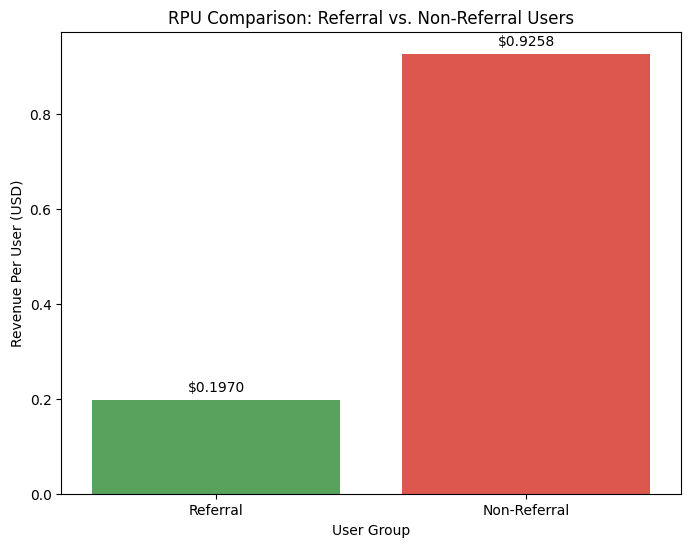

In [25]:
if __name__ == "__main__":
    calculate_rpu_comparison()